In [0]:
average_price = spark.table("avg_house_price")
immigration_pop = spark.table("immigration_population")
immigration_income = spark.table("immigration_median_income")
display(average_price)

Year,Province,Avg_price
2015,AB,432800
2015,BC,610000
2015,MB,283000
2015,NB,199800
2015,NL,299300
2015,NS,256100
2015,ONT,455000
2015,PEI,204200
2015,QC,305800
2015,SK,332600


In [0]:
display(immigration_pop)

Year,Province,Immigrants,Refugees
2010,Canada,167810,22925
2011,Canada,173155,23580
2012,Canada,176885,24200
2013,Canada,179535,24790
2014,Canada,180040,25370
2015,Canada,180235,25870
2016,Canada,180765,26315
2017,Canada,181045,26780
2018,Canada,182750,27435
2019,Canada,184460,28025


In [0]:
display(immigration_income)

Year,Province,Immigrant_median_income
2010,Canada,20900
2011,Canada,23600
2012,Canada,25900
2013,Canada,27900
2014,Canada,29400
2015,Canada,31200
2016,Canada,32100
2017,Canada,33700
2018,Canada,35700
2019,Canada,36900


## 0.Data Cleaning & Preparation

In [0]:
average_price= average_price.dropna().distinct()
average_price.show()

+----+--------+---------+
|Year|Province|Avg_price|
+----+--------+---------+
|2015|      AB|   432800|
|2015|      BC|   610000|
|2015|      MB|   283000|
|2015|      NB|   199800|
|2015|      NL|   299300|
|2015|      NS|   256100|
|2015|     ONT|   455000|
|2015|     PEI|   204200|
|2015|      QC|   305800|
|2015|      SK|   332600|
|2016|      AB|   425900|
|2016|      BC|   717600|
|2016|      MB|   288800|
|2016|      NB|   207800|
|2016|      NL|   298800|
|2016|      NS|   261800|
|2016|     ONT|   515200|
|2016|     PEI|   214700|
|2016|      QC|   316000|
|2016|      SK|   332700|
+----+--------+---------+
only showing top 20 rows


In [0]:
immigration_pop= immigration_pop.dropna().distinct()
immigration_pop.show()

+----+--------+----------+--------+
|Year|Province|Immigrants|Refugees|
+----+--------+----------+--------+
|2010|  Canada|    167810|   22925|
|2011|  Canada|    173155|   23580|
|2012|  Canada|    176885|   24200|
|2013|  Canada|    179535|   24790|
|2014|  Canada|    180040|   25370|
|2015|  Canada|    180235|   25870|
|2016|  Canada|    180765|   26315|
|2017|  Canada|    181045|   26780|
|2018|  Canada|    182750|   27435|
|2019|  Canada|    184460|   28025|
|2010|      NL|       335|      85|
|2011|      NL|       325|      85|
|2012|      NL|       320|      85|
|2013|      NL|       315|      65|
|2014|      NL|       305|      75|
|2015|      NL|       315|      75|
|2016|      NL|       300|      45|
|2017|      NL|       260|      25|
|2018|      NL|       265|      35|
|2019|      NL|       260|      40|
+----+--------+----------+--------+
only showing top 20 rows


In [0]:
immigration_income= immigration_income.dropna().distinct()
immigration_income.show()

+----+--------+-----------------------+
|Year|Province|Immigrant_median_income|
+----+--------+-----------------------+
|2010|  Canada|                  20900|
|2011|  Canada|                  23600|
|2012|  Canada|                  25900|
|2013|  Canada|                  27900|
|2014|  Canada|                  29400|
|2015|  Canada|                  31200|
|2016|  Canada|                  32100|
|2017|  Canada|                  33700|
|2018|  Canada|                  35700|
|2019|  Canada|                  36900|
|2010|      NL|                  23300|
|2011|      NL|                  29500|
|2012|      NL|                  34700|
|2013|      NL|                  31700|
|2014|      NL|                  36300|
|2015|      NL|                  35200|
|2016|      NL|                  40700|
|2017|      NL|                  45600|
|2018|      NL|                  45100|
|2019|      NL|                  47100|
+----+--------+-----------------------+
only showing top 20 rows


In [0]:
from pyspark.sql.functions import col
average_price = average_price.withColumn("Year", col("Year").cast("int"))\
    .withColumn("Avg_price", col("Avg_price").cast("float"))
average_price.printSchema()
average_price.describe().show()

root
 |-- Year: integer (nullable = true)
 |-- Province: string (nullable = true)
 |-- Avg_price: float (nullable = true)

+-------+------------------+--------+------------------+
|summary|              Year|Province|         Avg_price|
+-------+------------------+--------+------------------+
|  count|                70|      70|                70|
|   mean|            2018.0|    NULL|383004.28571428574|
| stddev|2.0144406207413397|    NULL|180166.99293623486|
|    min|              2015|      AB|          199800.0|
|    max|              2021|      SK|          887800.0|
+-------+------------------+--------+------------------+



In [0]:
immigration_pop.describe()

DataFrame[summary: string, Year: string, Province: string, Immigrants: string, Refugees: string]

In [0]:
immigration_pop = immigration_pop.withColumn("Year", col("Year").cast("int"))\
    .withColumn("Immigrants", col("Immigrants").cast("float"))\
    .withColumn("Refugees", col("Refugees").cast("float"))
immigration_pop.printSchema()
immigration_pop.describe().show()

root
 |-- Year: integer (nullable = true)
 |-- Province: string (nullable = true)
 |-- Immigrants: float (nullable = true)
 |-- Refugees: float (nullable = true)

+-------+-----------------+--------+----------------+-----------------+
|summary|             Year|Province|      Immigrants|         Refugees|
+-------+-----------------+--------+----------------+-----------------+
|  count|              120|     120|             120|              120|
|   mean|           2014.5|    NULL|       29777.875|          4253.75|
| stddev|2.884324484362402|    NULL|50055.6925114354|7491.610552909874|
|    min|             2010|      AB|           220.0|             15.0|
|    max|             2019|      SK|        184460.0|          28025.0|
+-------+-----------------+--------+----------------+-----------------+



In [0]:
immigration_income.describe()

DataFrame[summary: string, Year: string, Province: string, Immigrant_median_income: string]

In [0]:
immigration_income = immigration_income.withColumn("Year", col("Year").cast("int"))\
    .withColumn("Immigrant_median_income", col("Immigrant_median_income").cast("float"))
immigration_income.printSchema()
immigration_income.describe().show()

root
 |-- Year: integer (nullable = true)
 |-- Province: string (nullable = true)
 |-- Immigrant_median_income: float (nullable = true)

+-------+-----------------+--------+-----------------------+
|summary|             Year|Province|Immigrant_median_income|
+-------+-----------------+--------+-----------------------+
|  count|              120|     120|                    120|
|   mean|           2014.5|    NULL|     31731.666666666668|
| stddev|2.884324484362402|    NULL|      8632.720471849994|
|    min|             2010|      AB|                13900.0|
|    max|             2019|      SK|                60100.0|
+-------+-----------------+--------+-----------------------+



In [0]:
df1 = average_price.join(immigration_pop, ["Year","Province"],"inner")
df1.show()

+----+--------+---------+----------+--------+
|Year|Province|Avg_price|Immigrants|Refugees|
+----+--------+---------+----------+--------+
|2019|      NL| 272700.0|     260.0|    40.0|
|2016|      NB| 207800.0|     805.0|    95.0|
|2019|      NB| 218100.0|     815.0|    85.0|
|2017|      QC| 327900.0|   30905.0|  3535.0|
|2017|      AB| 429800.0|   24175.0|  4145.0|
|2018|      BC| 816300.0|   31800.0|  1925.0|
|2017|     ONT| 600300.0|   78440.0| 15040.0|
|2015|      AB| 432800.0|   24315.0|  4150.0|
|2017|      BC| 775400.0|   31635.0|  1860.0|
|2016|      NL| 298800.0|     300.0|    45.0|
|2019|      QC| 359600.0|   31550.0|  3690.0|
|2016|      SK| 332700.0|    4785.0|   830.0|
|2015|      BC| 610000.0|   31305.0|  1800.0|
|2018|      NB| 214800.0|     800.0|    80.0|
|2015|     ONT| 455000.0|   77330.0| 14110.0|
|2016|      NS| 261800.0|    1290.0|   150.0|
|2019|      MB| 305200.0|    8295.0|   980.0|
|2019|      BC| 785500.0|   32025.0|  1950.0|
|2019|      NS| 282700.0|    1300.

In [0]:
df1.printSchema()
df1.describe().show()

root
 |-- Year: integer (nullable = true)
 |-- Province: string (nullable = true)
 |-- Avg_price: float (nullable = true)
 |-- Immigrants: float (nullable = true)
 |-- Refugees: float (nullable = true)

+-------+------------------+--------+------------------+------------------+------------------+
|summary|              Year|Province|         Avg_price|        Immigrants|          Refugees|
+-------+------------------+--------+------------------+------------------+------------------+
|  count|                50|      50|                50|                50|                50|
|   mean|            2017.0|    NULL|          369384.0|           18156.3|            2684.4|
| stddev|1.4285714285714286|    NULL|161808.95936446858|23817.710114791567|4403.7090860189355|
|    min|              2015|      AB|          199800.0|             220.0|              25.0|
|    max|              2019|      SK|          816300.0|           80275.0|           15935.0|
+-------+------------------+--------+

# Analyze and Visualization

## The Impact of Immigrant Population on Housing Price

In [0]:
from pyspark.sql.functions import sum
initial_total_immigrants_pop = df1.filter(df1["Province"] != "Canada" )\
    .groupBy("Province")\
    .agg(sum("Immigrants").alias("Total Immigrants"))
initial_total_immigrants_pop.show()

+--------+----------------+
|Province|Total Immigrants|
+--------+----------------+
|      NL|          1400.0|
|      NB|          4020.0|
|      QC|        155930.0|
|      AB|        121745.0|
|      BC|        158245.0|
|     ONT|        393500.0|
|      SK|         23770.0|
|      NS|          6510.0|
|      MB|         41460.0|
|     PEI|          1235.0|
+--------+----------------+



In [0]:
df1 = df1.filter(df1["Province"] != "Canada")
df1.show()

+----+--------+---------+----------+--------+
|Year|Province|Avg_price|Immigrants|Refugees|
+----+--------+---------+----------+--------+
|2019|      NL| 272700.0|     260.0|    40.0|
|2016|      NB| 207800.0|     805.0|    95.0|
|2019|      NB| 218100.0|     815.0|    85.0|
|2017|      QC| 327900.0|   30905.0|  3535.0|
|2017|      AB| 429800.0|   24175.0|  4145.0|
|2018|      BC| 816300.0|   31800.0|  1925.0|
|2017|     ONT| 600300.0|   78440.0| 15040.0|
|2015|      AB| 432800.0|   24315.0|  4150.0|
|2017|      BC| 775400.0|   31635.0|  1860.0|
|2016|      NL| 298800.0|     300.0|    45.0|
|2019|      QC| 359600.0|   31550.0|  3690.0|
|2016|      SK| 332700.0|    4785.0|   830.0|
|2015|      BC| 610000.0|   31305.0|  1800.0|
|2018|      NB| 214800.0|     800.0|    80.0|
|2015|     ONT| 455000.0|   77330.0| 14110.0|
|2016|      NS| 261800.0|    1290.0|   150.0|
|2019|      MB| 305200.0|    8295.0|   980.0|
|2019|      BC| 785500.0|   32025.0|  1950.0|
|2019|      NS| 282700.0|    1300.

In [0]:
from pyspark.sql.functions import to_date, concat, lit
df1 = df1.withColumn("Date", to_date(concat(col("Year"), lit("-01-01"))))
df1.show()

+----+--------+---------+----------+--------+----------+
|Year|Province|Avg_price|Immigrants|Refugees|      Date|
+----+--------+---------+----------+--------+----------+
|2019|      NL| 272700.0|     260.0|    40.0|2019-01-01|
|2016|      NB| 207800.0|     805.0|    95.0|2016-01-01|
|2019|      NB| 218100.0|     815.0|    85.0|2019-01-01|
|2017|      QC| 327900.0|   30905.0|  3535.0|2017-01-01|
|2017|      AB| 429800.0|   24175.0|  4145.0|2017-01-01|
|2018|      BC| 816300.0|   31800.0|  1925.0|2018-01-01|
|2017|     ONT| 600300.0|   78440.0| 15040.0|2017-01-01|
|2015|      AB| 432800.0|   24315.0|  4150.0|2015-01-01|
|2017|      BC| 775400.0|   31635.0|  1860.0|2017-01-01|
|2016|      NL| 298800.0|     300.0|    45.0|2016-01-01|
|2019|      QC| 359600.0|   31550.0|  3690.0|2019-01-01|
|2016|      SK| 332700.0|    4785.0|   830.0|2016-01-01|
|2015|      BC| 610000.0|   31305.0|  1800.0|2015-01-01|
|2018|      NB| 214800.0|     800.0|    80.0|2018-01-01|
|2015|     ONT| 455000.0|   773

In [0]:
from pyspark.sql.functions import when
df1 = df1.withColumn("Immigration Level",when(col("Immigrants")>50000,"High")\
    .when(col("Immigrants")>10000,"Medium")\
    .otherwise("Low"))
df1.show()

+----+--------+---------+----------+--------+----------+-----------------+
|Year|Province|Avg_price|Immigrants|Refugees|      Date|Immigration Level|
+----+--------+---------+----------+--------+----------+-----------------+
|2019|      NL| 272700.0|     260.0|    40.0|2019-01-01|              Low|
|2016|      NB| 207800.0|     805.0|    95.0|2016-01-01|              Low|
|2019|      NB| 218100.0|     815.0|    85.0|2019-01-01|              Low|
|2017|      QC| 327900.0|   30905.0|  3535.0|2017-01-01|           Medium|
|2017|      AB| 429800.0|   24175.0|  4145.0|2017-01-01|           Medium|
|2018|      BC| 816300.0|   31800.0|  1925.0|2018-01-01|           Medium|
|2017|     ONT| 600300.0|   78440.0| 15040.0|2017-01-01|             High|
|2015|      AB| 432800.0|   24315.0|  4150.0|2015-01-01|           Medium|
|2017|      BC| 775400.0|   31635.0|  1860.0|2017-01-01|           Medium|
|2016|      NL| 298800.0|     300.0|    45.0|2016-01-01|              Low|
|2019|      QC| 359600.0|

In [0]:
import plotly.express as px
pdf = (
    df1.select("Province", "Year", "Immigrants")
       .orderBy("Province", "Year")
       .toPandas()
)
fig = px.line(
    pdf,
    x="Year",
    y="Immigrants",
    color="Province",
    markers=True,
    title="Immigration Change Over Time by Province"
)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of Immigrants",
    legend_title="Province"
)
fig.show()

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import lag, round
windowSpec = Window.partitionBy("Province").orderBy("Year")
df_growth = df1.withColumn("Prev_Year_Price", lag("Avg_price", 1).over(windowSpec)) \
               .withColumn("Price_Growth_%", 
                    round(((col("Avg_price") - col("Prev_Year_Price")) / col("Prev_Year_Price")) * 100, 2))
df_growth.select("Province", "Year", "Avg_price", "Price_Growth_%").show() 

+--------+----+---------+--------------+
|Province|Year|Avg_price|Price_Growth_%|
+--------+----+---------+--------------+
|      AB|2015| 432800.0|          NULL|
|      AB|2016| 425900.0|         -1.59|
|      AB|2017| 429800.0|          0.92|
|      AB|2018| 428500.0|          -0.3|
|      AB|2019| 420900.0|         -1.77|
|      BC|2015| 610000.0|          NULL|
|      BC|2016| 717600.0|         17.64|
|      BC|2017| 775400.0|          8.05|
|      BC|2018| 816300.0|          5.27|
|      BC|2019| 785500.0|         -3.77|
|      MB|2015| 283000.0|          NULL|
|      MB|2016| 288800.0|          2.05|
|      MB|2017| 297400.0|          2.98|
|      MB|2018| 300000.0|          0.87|
|      MB|2019| 305200.0|          1.73|
|      NB|2015| 199800.0|          NULL|
|      NB|2016| 207800.0|           4.0|
|      NB|2017| 208200.0|          0.19|
|      NB|2018| 214800.0|          3.17|
|      NB|2019| 218100.0|          1.54|
+--------+----+---------+--------------+
only showing top

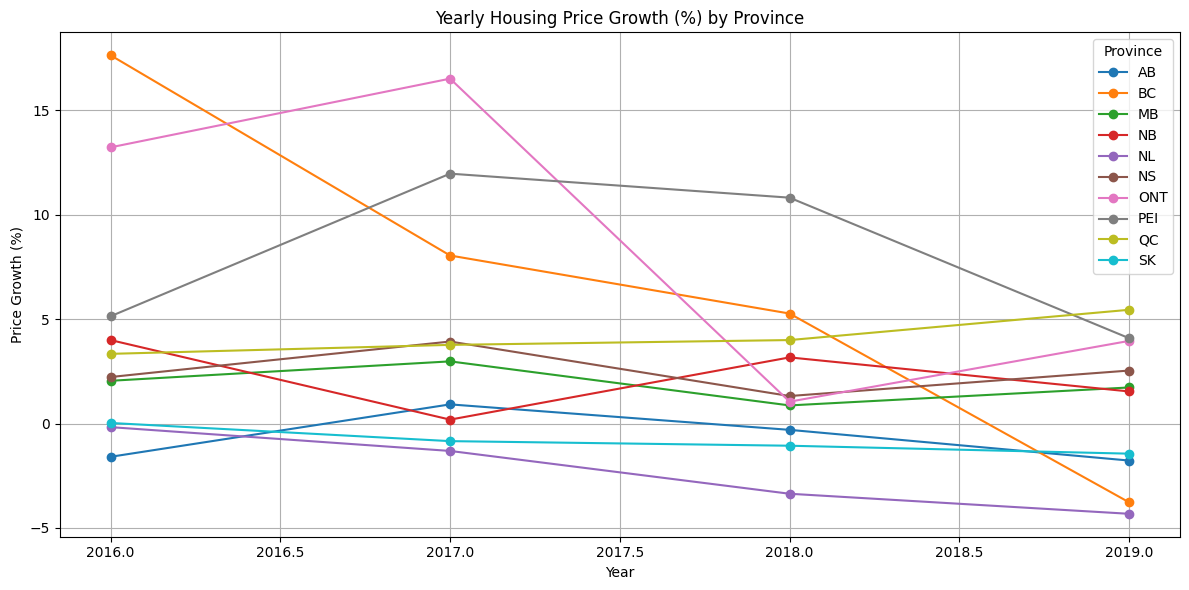

In [0]:
import matplotlib.pyplot as plt
pdf = df_growth.select("Province", "Year", "Price_Growth_%") \
               .orderBy("Province", "Year") \
               .toPandas()
plt.figure(figsize=(12, 6))
for province in pdf["Province"].unique():
    subset = pdf[pdf["Province"] == province]
    plt.plot(subset["Year"], subset["Price_Growth_%"], marker='o', label=province)

plt.title("Yearly Housing Price Growth (%) by Province")
plt.xlabel("Year")
plt.ylabel("Price Growth (%)")
plt.legend(title="Province")
plt.grid(True)
plt.tight_layout()
plt.show()


In [0]:
from pyspark.sql.functions import avg
final_analysis = df_growth.groupBy("Immigration Level") \
    .agg(
        avg("Price_Growth_%").alias("Avg_Annual_Inflation"),
        sum("Immigrants").alias("Total_Newcomers")
    ).orderBy("Avg_Annual_Inflation")

final_analysis.show()

+-----------------+--------------------+---------------+
|Immigration Level|Avg_Annual_Inflation|Total_Newcomers|
+-----------------+--------------------+---------------+
|              Low|  1.9208333333333332|        78395.0|
|           Medium|  3.4175000000000004|       435920.0|
|             High|                8.69|       393500.0|
+-----------------+--------------------+---------------+



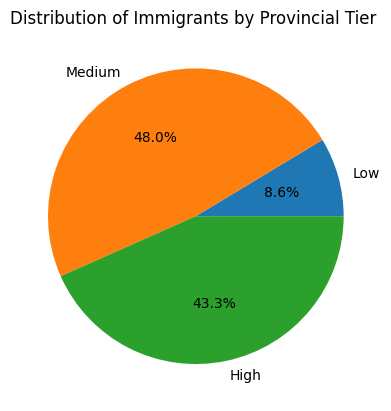

In [0]:
import matplotlib.pyplot as plt
data_rows = final_analysis.collect()
labels = [row["Immigration Level"] for row in data_rows]
values = [row["Total_Newcomers"] for row in data_rows]
plt.pie(
    values, 
    labels=labels,
    autopct='%1.1f%%'
)
plt.title('Distribution of Immigrants by Provincial Tier ')
plt.show()

## Immigrant Income Growth

In [0]:
df2 = average_price.join(immigration_income, ["Year","Province"],"inner")
df2.show()

+----+--------+---------+-----------------------+
|Year|Province|Avg_price|Immigrant_median_income|
+----+--------+---------+-----------------------+
|2016|      NL| 298800.0|                40700.0|
|2016|      NS| 261800.0|                32000.0|
|2018|      MB| 300000.0|                35000.0|
|2016|     PEI| 214700.0|                23200.0|
|2015|      NS| 256100.0|                31600.0|
|2019|      NB| 218100.0|                31900.0|
|2017|     ONT| 600300.0|                31900.0|
|2017|     PEI| 240400.0|                22300.0|
|2019|     PEI| 277300.0|                27500.0|
|2019|      SK| 321700.0|                41300.0|
|2018|      NB| 214800.0|                31800.0|
|2016|      QC| 316000.0|                30400.0|
|2017|      QC| 327900.0|                32500.0|
|2017|      AB| 429800.0|                41100.0|
|2019|      BC| 785500.0|                36400.0|
|2016|     ONT| 515200.0|                30500.0|
|2015|      MB| 283000.0|                32700.0|


In [0]:
pdf_income = (
    df2.select("Province", "Year", "Immigrant_median_income")
       .orderBy("Province", "Year")
       .toPandas()
)
import plotly.express as px
fig = px.line(
    pdf_income,
    x="Year",
    y="Immigrant_median_income",
    color="Province",
    markers=True,
    title="Growth of Immigrant Median Income by Province Over Time"
)
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Median Income",
    legend_title="Province"
)
fig.show()


In [0]:
average_income= df2.groupBy("Province").agg(avg("Immigrant_median_income").alias("Avg_income"))
average_income.show()


+--------+----------+
|Province|Avg_income|
+--------+----------+
|      NL|   42740.0|
|      NS|   33600.0|
|      MB|   34260.0|
|     PEI|   22400.0|
|      NB|   30580.0|
|     ONT|   32280.0|
|      SK|   40040.0|
|      QC|   32560.0|
|      AB|   41660.0|
|      BC|   32560.0|
+--------+----------+



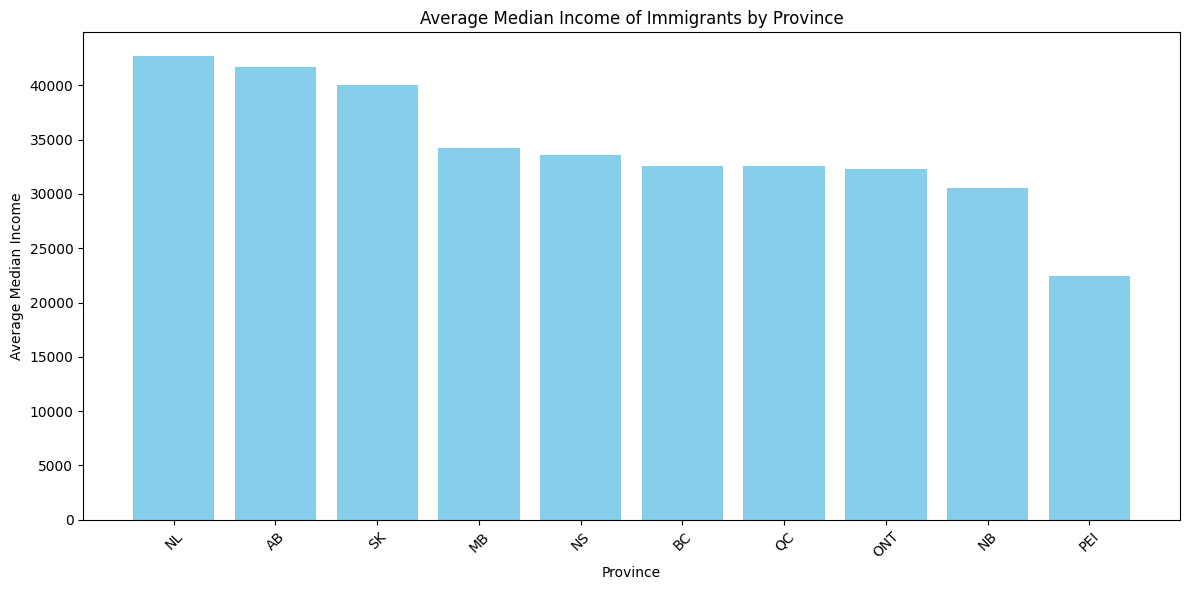

In [0]:
import matplotlib.pyplot as plt
pdf = average_income.orderBy("Province").toPandas()
pdf = pdf.sort_values(by="Avg_income", ascending = False)

plt.figure(figsize=(12, 6))
plt.bar(pdf["Province"], pdf["Avg_income"], color="skyblue")
plt.title("Average Median Income of Immigrants by Province")
plt.xlabel("Province")
plt.ylabel("Average Median Income")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [0]:
df1 = average_price.join(immigration_pop, ["Year","Province"],"inner")
df_total = df1.join(immigration_income,["Year","Province"], "inner")
df_total = df_total.filter(df_total["Province"] != "Canada")
df_total.show()


+----+--------+---------+----------+--------+-----------------------+
|Year|Province|Avg_price|Immigrants|Refugees|Immigrant_median_income|
+----+--------+---------+----------+--------+-----------------------+
|2016|      NL| 298800.0|     300.0|    45.0|                40700.0|
|2016|      NS| 261800.0|    1290.0|   150.0|                32000.0|
|2018|      MB| 300000.0|    8305.0|  1025.0|                35000.0|
|2016|     PEI| 214700.0|     255.0|    70.0|                23200.0|
|2015|      NS| 256100.0|    1325.0|   175.0|                31600.0|
|2019|      NB| 218100.0|     815.0|    85.0|                31900.0|
|2017|     ONT| 600300.0|   78440.0| 15040.0|                31900.0|
|2017|     PEI| 240400.0|     250.0|    75.0|                22300.0|
|2019|     PEI| 277300.0|     220.0|    60.0|                27500.0|
|2019|      SK| 321700.0|    4755.0|   775.0|                41300.0|
|2018|      NB| 214800.0|     800.0|    80.0|                31800.0|
|2016|      QC| 3160

## The Interaction between Immigrant Population & Immigrant Median 
## Income with Housing Price

In [0]:
from pyspark.sql.functions import median
chart_data = df_total.groupBy("Year").agg(
    median("Immigrants").alias("Median_Pop"),
    median("Immigrant_median_income").alias("Median_Income"),
    avg("Avg_price").alias("Avg_Price")
).orderBy("Year").collect()

In [0]:
years = [row["Year"] for row in chart_data]
pop = [row["Median_Pop"] for row in chart_data]
income = [row["Median_Income"] for row in chart_data]
prices = [row["Avg_Price"] for row in chart_data]

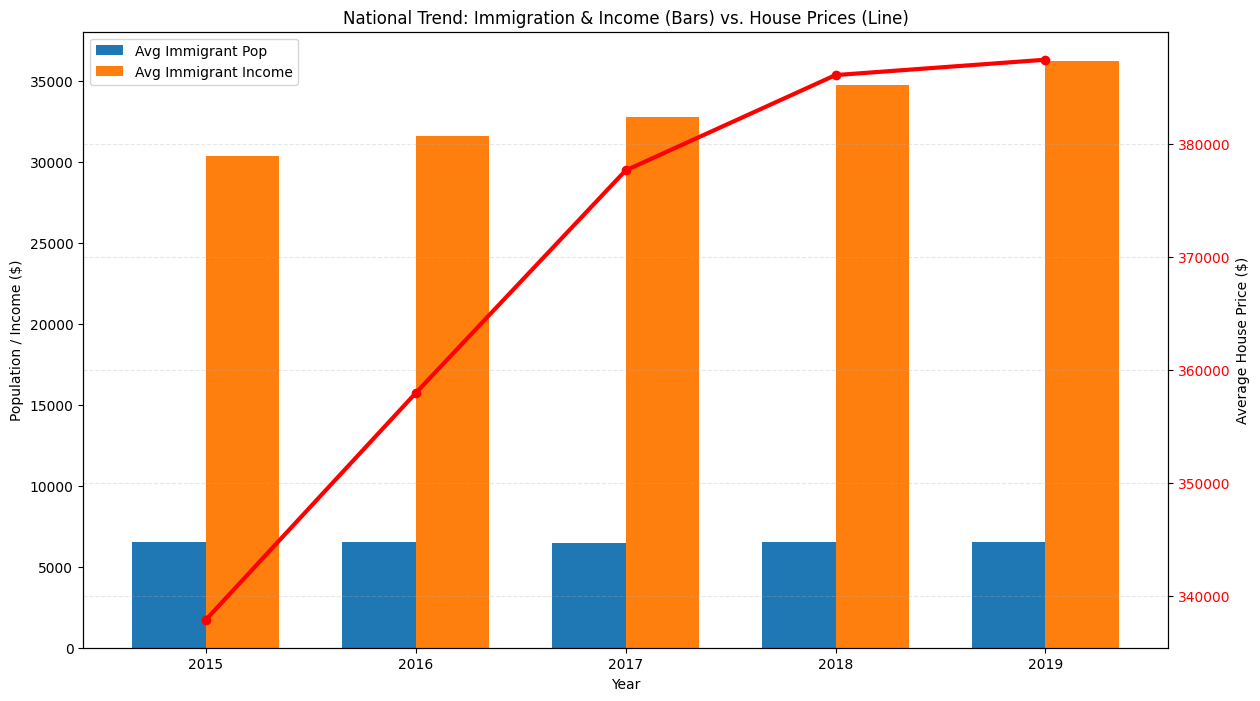

In [0]:
# x1 is the center/left position, x2 is shifted to the right by the bar width
x_indices = list(range(len(years)))
width = 0.35
x2_indices = [i + width for i in x_indices]
center_indices = [i + width/2 for i in x_indices] # Where labels will go

fig, ax1 = plt.subplots(figsize=(14, 8))

bar1 = ax1.bar(x_indices, pop, width, label='Avg Immigrant Pop')
bar2 = ax1.bar(x2_indices, income, width, label='Avg Immigrant Income')

ax1.set_xlabel('Year')
ax1.set_ylabel('Population / Income ($)')
ax1.set_xticks(center_indices) 
ax1.set_xticklabels(years)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(center_indices, prices, color='red', marker='o', linewidth=3, label='Avg House Price')
ax2.set_ylabel('Average House Price ($)')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('National Trend: Immigration & Income (Bars) vs. House Prices (Line)')
plt.grid(axis='y', linestyle='--', alpha=0.3)